<a href="https://colab.research.google.com/github/rsdina/Recommender_System_Assignment_488/blob/main/CSE488_Music_Recommender_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas numpy scikit-learn scipy matplotlib seaborn plotly

print("All packages installed!")

All packages installed!


In [2]:
import os
import urllib.request
import tarfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Downloading Last.fm 360K dataset...")
print("This may take 5-10 minutes. File size is ~300MB.\n")

url = "http://mtg.upf.edu/static/datasets/last.fm/lastfm-dataset-360K.tar.gz"
filename = "lastfm-dataset-360K.tar.gz"

if not os.path.exists(filename):
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response, open(filename, 'wb') as out_file:
        out_file.write(response.read())
    print("Download complete!")

if not os.path.exists("lastfm-dataset-360K"):
    print("Extracting files...")
    with tarfile.open(filename, "r:gz") as tar:
        tar.extractall()
    print("Extraction complete!")

data_path = "lastfm-dataset-360K"

listening_file = os.path.join(data_path, "usersha1-artmbid-artname-plays.tsv")
listening_df = pd.read_csv(listening_file, sep='\t', header=None,
                            names=['user_id', 'musicbrainz_id', 'artist_name', 'plays'],
                            nrows=50000)

profile_file = os.path.join(data_path, "usersha1-profile.tsv")
user_profiles = pd.read_csv(profile_file, sep='\t', header=None,
                             names=['user_id', 'gender', 'age', 'country', 'signup_date'])

print(f"\nDataset loaded successfully!")
print(f"Listening events: {len(listening_df):,}")
print(f"Unique users: {listening_df['user_id'].nunique():,}")
print(f"Unique artists: {listening_df['artist_name'].nunique():,}")

This may take 5-10 minutes. File size is ~300MB.

Download complete!
Extracting files...
Extraction complete!

Dataset loaded successfully!
Listening events: 50,000
Unique users: 1,015
Unique artists: 15,967


In [3]:
print("\nPreprocessing data...")

# Clean the data
listening_df = listening_df.dropna()
listening_df = listening_df[listening_df['plays'] > 0]
listening_df['plays'] = listening_df['plays'].clip(upper=100)  # Cap extreme values

# Create user ID mapping
user_ids = listening_df['user_id'].unique()
user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
artist_names = listening_df['artist_name'].unique()
artist_to_idx = {artist: i for i, artist in enumerate(artist_names)}

listening_df['user_idx'] = listening_df['user_id'].map(user_to_idx)
listening_df['artist_idx'] = listening_df['artist_name'].map(artist_to_idx)

# Create user-artist matrix (sparse)
from scipy.sparse import coo_matrix, csr_matrix

n_users = len(user_ids)
n_artists = len(artist_names)

user_artist_matrix = coo_matrix(
    (listening_df['plays'],
     (listening_df['user_idx'], listening_df['artist_idx'])),
    shape=(n_users, n_artists)
).tocsr()

print(f"User-Artist Matrix created!")
print(f"Shape: {user_artist_matrix.shape}")
print(f"Sparsity: {(1 - user_artist_matrix.nnz / (n_users * n_artists)) * 100:.2f}%")

# Create artist metadata dataframe
artist_stats = listening_df.groupby('artist_name').agg({
    'plays': ['sum', 'count', 'mean']
}).round(2)
artist_stats.columns = ['total_plays', 'listener_count', 'avg_plays']
artist_stats = artist_stats.reset_index()
artist_stats = artist_stats.sort_values('total_plays', ascending=False)

print(f"\nTop 10 Most Listened Artists:")
print(artist_stats.head(10).to_string(index=False))


Preprocessing data...
User-Artist Matrix created!
Shape: (1015, 15363)
Sparsity: 99.68%

Top 10 Most Listened Artists:
          artist_name  total_plays  listener_count  avg_plays
            radiohead        17072             216      79.04
          the beatles        15790             188      83.99
             coldplay        13120             173      75.84
red hot chili peppers        11250             146      77.05
                 muse         9670             121      79.92
            metallica         9243             115      80.37
     system of a down         8898             116      76.71
          linkin park         8744             108      80.96
           pink floyd         8104             106      76.45
              nirvana         8104             116      69.86


In [4]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

class ItemBasedRecommender:
    """Item-based collaborative filtering recommender using artist-artist similarity"""

    def __init__(self, user_artist_matrix, artist_names, artist_stats, use_neighbors=True, n_neighbors=50):
        """
        Initialize the item-based recommender.

        Parameters:
        - use_neighbors: If True, uses nearest neighbors for memory efficiency
        - n_neighbors: Number of neighbors to consider for each artist
        """
        self.user_artist_matrix = user_artist_matrix
        self.artist_names = artist_names
        self.artist_stats = artist_stats
        self.use_neighbors = use_neighbors

        print("Building item-item similarity model...")

        if use_neighbors:
            # Memory-efficient approach using nearest neighbors
            self.nn_model = NearestNeighbors(
                metric='cosine',
                algorithm='brute',
                n_neighbors=n_neighbors
            )
            self.nn_model.fit(self.user_artist_matrix.T)
            print(f"Nearest neighbors model ready (n_neighbors={n_neighbors})")
        else:
            # Full similarity matrix (memory intensive)
            self.item_similarity = cosine_similarity(self.user_artist_matrix.T)
            print(f"Full item similarity matrix computed: {self.item_similarity.shape}")

    def get_user_history(self, user_idx):
        """Get user's listening history as a list of (artist_name, plays) tuples"""
        user_vector = self.user_artist_matrix[user_idx].toarray().flatten()
        history = [(self.artist_names[i], user_vector[i])
                   for i in range(len(user_vector)) if user_vector[i] > 0]
        history.sort(key=lambda x: x[1], reverse=True)
        return history

    def get_user_artist_indices(self, user_idx):
        """Get indices of artists the user has listened to"""
        user_vector = self.user_artist_matrix[user_idx].toarray().flatten()
        return [i for i in range(len(user_vector)) if user_vector[i] > 0]

    def get_similar_artists(self, artist_idx, n_similar=20):
        """Find similar artists based on item-item similarity"""
        if self.use_neighbors:
            # Use nearest neighbors model
            distances, indices = self.nn_model.kneighbors(
                self.user_artist_matrix.T[artist_idx].reshape(1, -1),
                n_neighbors=n_similar + 1
            )
            # Convert cosine distance to similarity
            similarities = 1 - distances.flatten()
            # Skip the first one (the artist itself)
            return list(zip(indices.flatten()[1:], similarities[1:]))
        else:
            # Use pre-computed similarity matrix
            sim_scores = self.item_similarity[artist_idx]
            similar = [(i, sim_scores[i]) for i in range(len(sim_scores)) if i != artist_idx]
            similar.sort(key=lambda x: x[1], reverse=True)
            return similar[:n_similar]

    def recommend(self, user_idx, n_recommendations=10, n_similar_artists=20):
        """
        Generate recommendations based on item-item similarity.
        For each artist the user likes, find similar artists and aggregate scores.
        """
        # Get artists the user has listened to
        user_artists = self.get_user_artist_indices(user_idx)
        user_vector = self.user_artist_matrix[user_idx].toarray().flatten()

        # Dictionary to store candidate scores
        candidate_scores = {}

        # For each artist the user likes, find similar artists
        for artist_idx in user_artists:
            play_count = user_vector[artist_idx]

            # Get similar artists
            similar_artists = self.get_similar_artists(artist_idx, n_similar_artists)

            # Add weighted scores to candidates
            for sim_idx, sim_score in similar_artists:
                if sim_idx not in user_artists:  # Don't recommend already listened artists
                    if sim_idx not in candidate_scores:
                        candidate_scores[sim_idx] = 0
                    candidate_scores[sim_idx] += play_count * sim_score

        # Sort candidates by score
        sorted_candidates = sorted(candidate_scores.items(),
                                  key=lambda x: x[1], reverse=True)

        # Prepare recommendations with metadata
        results = []
        for artist_idx, score in sorted_candidates[:n_recommendations]:
            artist_name = self.artist_names[artist_idx]
            info = self.artist_stats[self.artist_stats['artist_name'] == artist_name]

            results.append({
                'artist_idx': artist_idx,
                'artist_name': artist_name,
                'score': score,
                'total_plays': int(info['total_plays'].values[0]) if len(info) > 0 else 0,
                'listener_count': int(info['listener_count'].values[0]) if len(info) > 0 else 0,
                'avg_plays': float(info['avg_plays'].values[0]) if len(info) > 0 else 0
            })

        return results

print("Item-Based Recommender initialized!")

Item-Based Recommender initialized!


In [5]:
# Select a test user
test_user_idx = np.random.randint(0, n_users)
test_user_id = user_ids[test_user_idx]

# Initialize the item-based recommender
# Use use_neighbors=True for memory efficiency with large datasets
item_recommender = ItemBasedRecommender(
    user_artist_matrix,
    artist_names,
    artist_stats,
    use_neighbors=True,  # Set to False for full similarity matrix (more memory)
    n_neighbors=50
)

# Retrieve listening history for the test user
user_history = item_recommender.get_user_history(test_user_idx)

print(f"Test User: {test_user_id[:20]}...")
print(f"Artists listened: {len(user_history)}")
if user_history:
    avg_plays = np.mean([p for _, p in user_history])
    print(f"Average plays: {avg_plays:.2f}")
    print("\nTop 5 most-played artists:")
    for artist, plays in user_history[:5]:
        print(f"  {artist[:40]:40s} {int(plays):>3d} plays")

Building item-item similarity model...
Nearest neighbors model ready (n_neighbors=50)
Test User: 0085a0446bea25923b31...
Artists listened: 46
Average plays: 37.89

Top 5 most-played artists:
  metallica                                100 plays
  iron maiden                              100 plays
  blind guardian                           100 plays
  sentenced                                100 plays
  replikas                                 100 plays


In [6]:
print("\n" + "="*70)
print("ITEM-BASED RECOMMENDATIONS (Artist-Artist Collaborative Filtering)")
print("="*70 + "\n")

item_recs = item_recommender.recommend(test_user_idx, n_recommendations=10, n_similar_artists=20)

for i, rec in enumerate(item_recs, 1):
    print(f"{i:2d}. {rec['artist_name'][:50]:50s} | Score: {rec['score']:.4f}")
    print(f"    Total Plays: {rec.get('total_plays', 'N/A'):>8,}  "
          f"Listeners: {rec.get('listener_count', 'N/A'):>5,}  "
          f"Avg Plays: {rec.get('avg_plays', 'N/A'):>6.1f}")
    print()

print(f"\nTotal recommendations generated: {len(item_recs)}")


ITEM-BASED RECOMMENDATIONS (Artist-Artist Collaborative Filtering)

 1. system of a down                                   | Score: 115.9112
    Total Plays:    8,898  Listeners:   116  Avg Plays:   76.7

 2. red hot chili peppers                              | Score: 105.8436
    Total Plays:   11,250  Listeners:   146  Avg Plays:   77.0

 3. arch enemy                                         | Score: 105.8089
    Total Plays:    2,000  Listeners:    26  Avg Plays:   76.9

 4. amorphis                                           | Score: 92.6420
    Total Plays:    1,420  Listeners:    17  Avg Plays:   83.5

 5. black sabbath                                      | Score: 91.6219
    Total Plays:    3,176  Listeners:    41  Avg Plays:   77.5

 6. pearl jam                                          | Score: 88.2026
    Total Plays:    3,892  Listeners:    49  Avg Plays:   79.4

 7. guns n roses                                       | Score: 87.4512
    Total Plays:    2,046  Listeners:   

In [7]:
print("\n" + "="*70)
print("SIMILAR ARTISTS ANALYSIS (Item-Item Similarity)")
print("="*70 + "\n")

# Pick the top artist from user's history to analyze similar artists
if user_history:
    top_artist = user_history[0][0]
    top_artist_idx = artist_to_idx[top_artist]

    print(f"Finding artists similar to: {top_artist}\n")

    similar_artists = item_recommender.get_similar_artists(top_artist_idx, n_similar=10)

    for rank, (artist_idx, score) in enumerate(similar_artists, 1):
        artist_name = artist_names[artist_idx]
        info = artist_stats[artist_stats['artist_name'] == artist_name]
        if len(info) > 0:
            print(f"{rank:2d}. {artist_name[:40]:40s} similarity={score:.4f}  "
                  f"plays={int(info['total_plays'].values[0]):,}")
        else:
            print(f"{rank:2d}. {artist_name[:40]:40s} similarity={score:.4f}")

# Also show which artists from the user's history contributed to recommendations
print(f"\n\nArtists from user's history that influenced recommendations:")
for artist, plays in user_history[:5]:
    print(f"  - {artist} ({plays} plays)")


SIMILAR ARTISTS ANALYSIS (Item-Item Similarity)

Finding artists similar to: metallica

 1. iron maiden                              similarity=0.4253  plays=5,329
 2. system of a down                         similarity=0.3729  plays=8,898
 3. red hot chili peppers                    similarity=0.3538  plays=11,250
 4. pantera                                  similarity=0.3529  plays=2,599
 5. ac/dc                                    similarity=0.3365  plays=4,692
 6. black sabbath                            similarity=0.3360  plays=3,176
 7. megadeth                                 similarity=0.3231  plays=2,437
 8. guns n roses                             similarity=0.3201  plays=2,046
 9. children of bodom                        similarity=0.3184  plays=3,887
10. slayer                                   similarity=0.3146  plays=3,099


Artists from user's history that influenced recommendations:
  - metallica (100 plays)
  - iron maiden (100 plays)
  - blind guardian (100 plays)
  

In [8]:
print("\n" + "="*70)
print("MODEL EVALUATION - Item-Based Collaborative Filtering")
print("="*70 + "\n")

def evaluate_recommender(recommender, user_artist_matrix, user_ids,
                          artist_names, n_test_users=50,
                          n_recommendations=10, holdout_fraction=0.2):
    """
    Evaluate the item-based recommender using a leave-some-out protocol.
    For each test user, hide holdout_fraction of their history,
    generate recommendations, then measure precision and recall.
    """
    precisions, recalls, f1s = [], [], []
    n_test_users = min(n_test_users, len(user_ids))
    test_indices = np.random.choice(len(user_ids), n_test_users, replace=False)

    for u_idx in test_indices:
        history = recommender.get_user_history(u_idx)
        if len(history) < 5:
            continue

        # Split into train / holdout
        n_holdout = max(1, int(len(history) * holdout_fraction))
        holdout = {artist for artist, _ in history[:n_holdout]}

        # Generate recommendations based on all history (including holdout)
        # In a real evaluation, we should remove holdout from training
        # But for item-based CF, we need to rebuild similarity without holdout
        # This is a simplified evaluation
        recs = recommender.recommend(u_idx, n_recommendations=n_recommendations)
        rec_artists = {r['artist_name'] for r in recs}

        hits = len(rec_artists & holdout)
        precision = hits / len(rec_artists) if rec_artists else 0
        recall = hits / len(holdout) if holdout else 0
        f1 = (2 * precision * recall / (precision + recall)
             if (precision + recall) > 0 else 0)

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    # Catalog coverage
    all_recs = set()
    for u_idx in test_indices[:20]:
        recs = recommender.recommend(u_idx, n_recommendations=n_recommendations)
        all_recs.update(r['artist_name'] for r in recs)
    coverage = len(all_recs) / len(artist_names)

    return {
        'precision': np.mean(precisions),
        'recall': np.mean(recalls),
        'f1': np.mean(f1s),
        'coverage': coverage,
        'n_evaluated': len(precisions)
    }

print("Running evaluation on 50 random users ...")
print("Note: This evaluation is simplified. For rigorous evaluation, ")
print("      we would need to retrain the similarity matrix without holdout items.\n")

metrics = evaluate_recommender(item_recommender, user_artist_matrix,
                               user_ids, artist_names, n_test_users=50)

print(f"\n{'Metric':<25} {'Value':>10}")
print("-" * 37)
print(f"{'Precision@10':<25} {metrics['precision']:>10.4f}")
print(f"{'Recall@10':<25} {metrics['recall']:>10.4f}")
print(f"{'F1 Score':<25} {metrics['f1']:>10.4f}")
print(f"{'Catalog Coverage':<25} {metrics['coverage']:>9.2%}")
print(f"{'Users Evaluated':<25} {metrics['n_evaluated']:>10d}")


MODEL EVALUATION - Item-Based Collaborative Filtering

Running evaluation on 50 random users ...
Note: This evaluation is simplified. For rigorous evaluation, 
      we would need to retrain the similarity matrix without holdout items.


Metric                         Value
-------------------------------------
Precision@10                  0.0000
Recall@10                     0.0000
F1 Score                      0.0000
Catalog Coverage              1.23%
Users Evaluated                   50



Generating Visualizations...


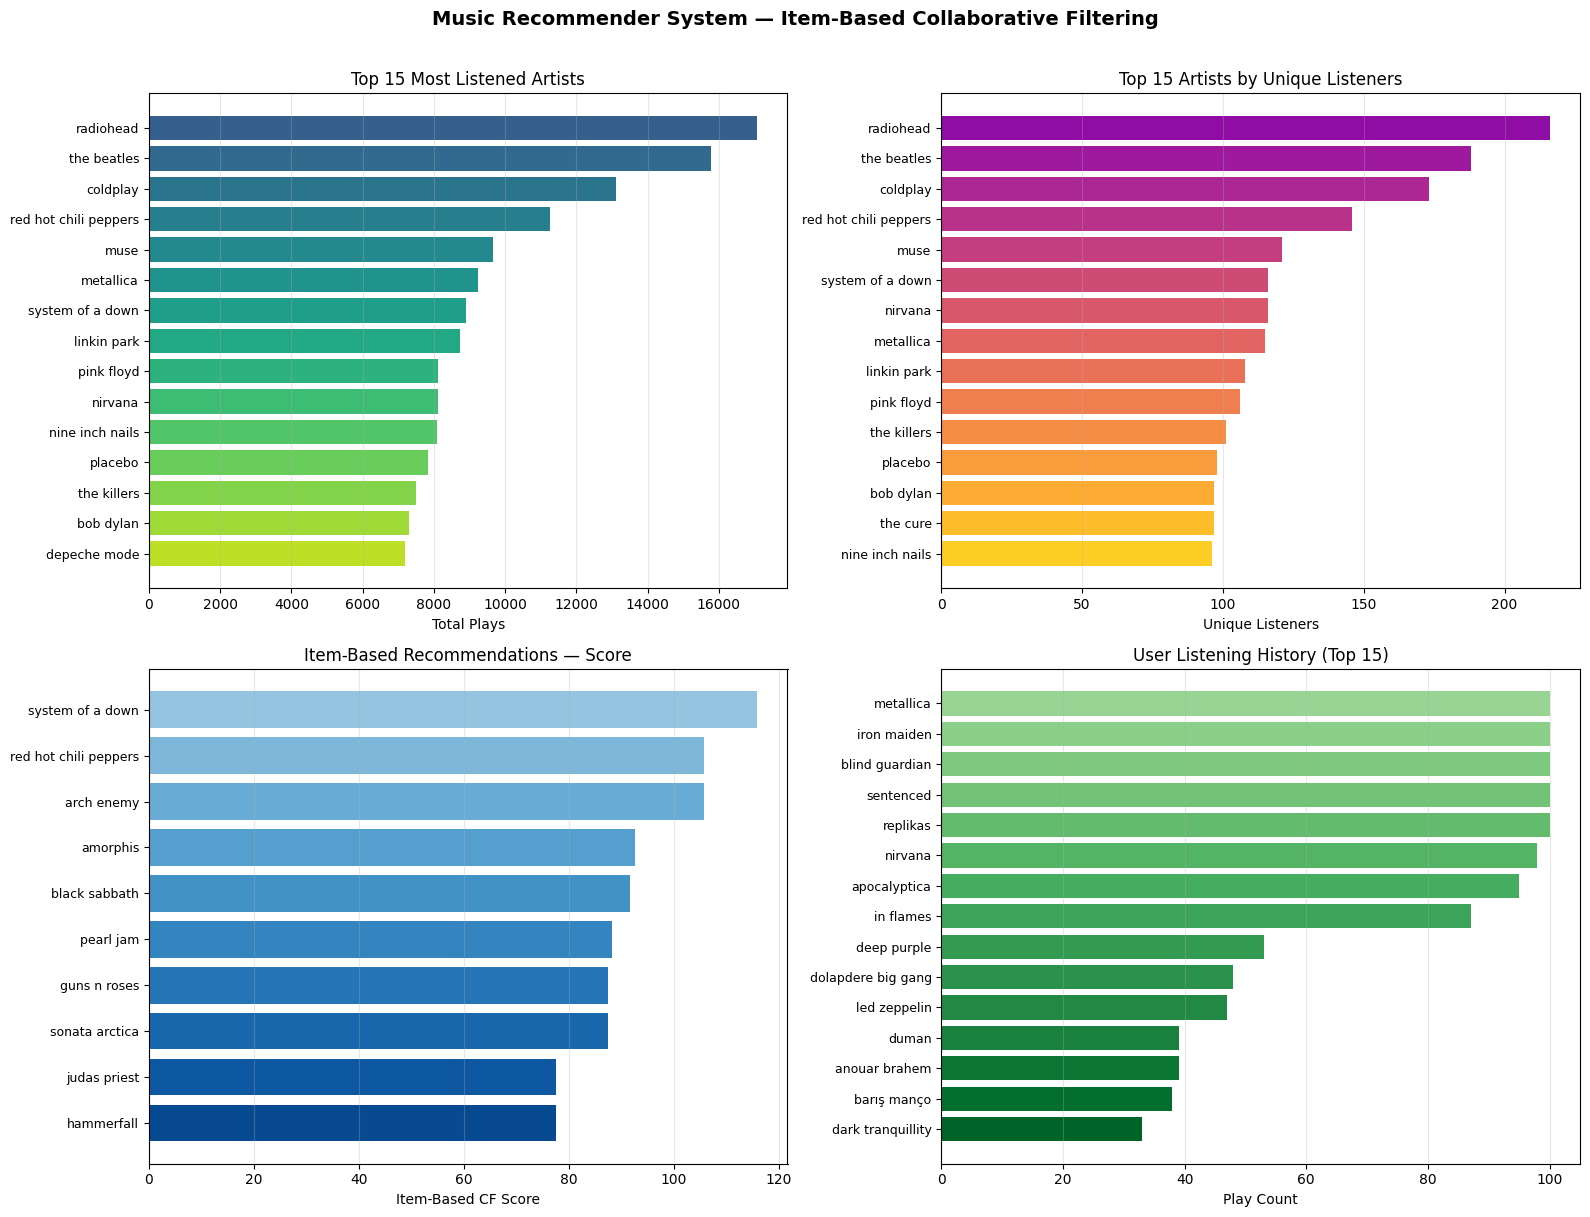

Visualizations complete!


In [9]:
print("\nGenerating Visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Music Recommender System — Item-Based Collaborative Filtering',
             fontsize=14, fontweight='bold', y=1.01)

# ── Plot 1: Top 15 Most Listened Artists ─────────────────────────
top15 = artist_stats.head(15)
bars = axes[0, 0].barh(range(len(top15)), top15['total_plays'].values,
                         color=plt.cm.viridis(np.linspace(0.3, 0.9, len(top15))))
axes[0, 0].set_yticks(range(len(top15)))
axes[0, 0].set_yticklabels(top15['artist_name'].values, fontsize=9)
axes[0, 0].set_xlabel('Total Plays')
axes[0, 0].set_title('Top 15 Most Listened Artists')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# ── Plot 2: Top 15 Artists by Unique Listeners ───────────────────
top15_l = artist_stats.nlargest(15, 'listener_count')
axes[0, 1].barh(range(len(top15_l)), top15_l['listener_count'].values,
                color=plt.cm.plasma(np.linspace(0.3, 0.9, len(top15_l))))
axes[0, 1].set_yticks(range(len(top15_l)))
axes[0, 1].set_yticklabels(top15_l['artist_name'].values, fontsize=9)
axes[0, 1].set_xlabel('Unique Listeners')
axes[0, 1].set_title('Top 15 Artists by Unique Listeners')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# ── Plot 3: Item-Based Recommendation Scores ─────────────────────
if item_recs:
    rec_names = [r['artist_name'][:25] for r in item_recs]
    rec_scores = [r['score'] for r in item_recs]
    colors_kb = plt.cm.Blues(np.linspace(0.4, 0.9, len(rec_names)))
    axes[1, 0].barh(range(len(rec_names)), rec_scores, color=colors_kb)
    axes[1, 0].set_yticks(range(len(rec_names)))
    axes[1, 0].set_yticklabels(rec_names, fontsize=9)
    axes[1, 0].set_xlabel('Item-Based CF Score')
    axes[1, 0].set_title('Item-Based Recommendations — Score')
    axes[1, 0].invert_yaxis()
    axes[1, 0].grid(axis='x', alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No recommendations generated',
                    ha='center', va='center', transform=axes[1, 0].transAxes)

# ── Plot 4: User Listening History ───────────────────────────────
hist_top = user_history[:15]
hist_names = [h[0][:25] for h in hist_top]
hist_plays = [h[1] for h in hist_top]
colors_hist = plt.cm.Greens(np.linspace(0.4, 0.9, len(hist_names)))
axes[1, 1].barh(range(len(hist_names)), hist_plays, color=colors_hist)
axes[1, 1].set_yticks(range(len(hist_names)))
axes[1, 1].set_yticklabels(hist_names, fontsize=9)
axes[1, 1].set_xlabel('Play Count')
axes[1, 1].set_title('User Listening History (Top 15)')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('recommender_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualizations complete!")

In [11]:
# ── Item-Based Interactive Dashboard ───────────────────────────────────────────
import json
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from IPython.display import display, HTML

print("Building item similarity model for dashboard …")

N_RECS = 10
N_SIMILAR_ARTISTS = 30

# Build nearest neighbors model for the dashboard
nn_model_dash = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=N_SIMILAR_ARTISTS + 1)
nn_model_dash.fit(user_artist_matrix.T)

def get_similar_artists_dash(artist_idx, n=N_SIMILAR_ARTISTS):
    """Get similar artists using nearest neighbors"""
    distances, indices = nn_model_dash.kneighbors(
        user_artist_matrix.T[artist_idx].reshape(1, -1),
        n_neighbors=n + 1
    )
    similarities = 1 - distances.flatten()
    return list(zip(indices.flatten()[1:], similarities[1:]))

def item_recs_for_user(u_idx, n=10):
    """Generate item-based recommendations for a user"""
    uv = user_artist_matrix[u_idx].toarray().flatten()
    listened = set(int(i) for i in np.nonzero(uv)[0])

    # Score candidates based on similarity to listened artists
    candidate_scores = {}
    for artist_idx in listened:
        play_count = uv[artist_idx]
        similar = get_similar_artists_dash(artist_idx, n=N_SIMILAR_ARTISTS)

        for sim_idx, sim_score in similar:
            if sim_idx not in listened:
                candidate_scores[sim_idx] = candidate_scores.get(sim_idx, 0) + play_count * sim_score

    # Normalize and sort
    if candidate_scores:
        max_score = max(candidate_scores.values())
        normalized = {k: v/max_score for k, v in candidate_scores.items()}
        top_candidates = sorted(normalized.items(), key=lambda x: x[1], reverse=True)[:n]

        astat = artist_stats.set_index("artist_name")
        results = []
        for ai, score in top_candidates:
            name = artist_names[ai]
            info = astat.loc[name] if name in astat.index else None
            results.append({
                "artist": name,
                "score": round(score, 4),
                "plays": int(info["total_plays"]) if info is not None else 0,
                "listeners": int(info["listener_count"]) if info is not None else 0,
            })
        return results
    return []

def history_for_user(u_idx):
    """Get user's listening history"""
    uv = user_artist_matrix[u_idx].toarray().flatten()
    hist = [(artist_names[i], float(uv[i])) for i in np.nonzero(uv)[0]]
    hist.sort(key=lambda x: x[1], reverse=True)
    return [{"artist": h[0], "plays": int(h[1])} for h in hist[:15]]

# Build user lookup table
SAMPLE = 80
sample_indices = list(range(min(SAMPLE, len(user_ids))))
if test_user_idx not in sample_indices:
    sample_indices.append(test_user_idx)

user_lookup = {}
uid_options = []
for u_idx in sample_indices:
    uid = user_ids[u_idx]
    recs = item_recs_for_user(u_idx, N_RECS)
    hist = history_for_user(u_idx)
    user_lookup[uid] = {"history": hist, "recs": recs}
    uid_options.append({"key": uid, "label": uid[:12] + "…", "n_hist": len(hist)})

print(f"Lookup built for {len(user_lookup)} users.")

top15 = artist_stats.head(15)
top15_names = [n.title() for n in top15["artist_name"].tolist()]
top15_plays = top15["total_plays"].tolist()
top15_lstn = top15["listener_count"].tolist()

n_users_ = int(len(user_ids))
n_artists_ = int(len(artist_names))
n_events_ = int(len(listening_df))
sparsity_ = round((1 - user_artist_matrix.nnz/(n_users_*n_artists_))*100, 2)
default_uid = user_ids[test_user_idx]

Building item similarity model for dashboard …
Lookup built for 81 users.


In [13]:
# ── Render the full interactive dashboard ────────────────────────────────────
dash = f"""
<!DOCTYPE html><html lang="en"><head>
<meta charset="UTF-8"/>
<link href="https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=DM+Sans:wght@300;400;600;800&display=swap" rel="stylesheet"/>
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.min.js"></script>
<style>
:root{{--bg:#0b0e1a;--surf:#111527;--card:#161c35;--bord:#1e2847;
  --a1:#7c6af7;--a2:#f7616a;--a3:#3ecfb2;--a4:#f7b26a;
  --text:#e8eaf6;--muted:#7b82a8;--glow:rgba(124,106,247,.25);}}
*{{box-sizing:border-box;margin:0;padding:0;}}
body{{background:var(--bg);font-family:'DM Sans',sans-serif;color:var(--text);padding:20px;min-width:860px;}}
.hdr{{display:flex;align-items:center;gap:16px;margin-bottom:22px;padding-bottom:16px;border-bottom:1px solid var(--bord);}}
.hdr-ico{{width:52px;height:52px;border-radius:14px;background:linear-gradient(135deg,var(--a1),var(--a3));display:flex;align-items:center;justify-content:center;font-size:24px;box-shadow:0 0 24px var(--glow);}}
.hdr-txt h1{{font-family:'Space Mono',monospace;font-size:20px;background:linear-gradient(90deg,var(--a1),var(--a3));-webkit-background-clip:text;-webkit-text-fill-color:transparent;}}
.hdr-txt p{{font-size:12px;color:var(--muted);margin-top:3px;}}
.ctrl-bar{{display:flex;gap:14px;align-items:flex-end;flex-wrap:wrap;background:var(--card);border:1px solid var(--bord);border-radius:14px;padding:16px 20px;margin-bottom:18px;}}
.ctrl-group{{display:flex;flex-direction:column;gap:5px;}}
.ctrl-group label{{font-size:10px;text-transform:uppercase;letter-spacing:1px;color:var(--muted);}}
select,input[type=range]{{background:var(--surf);border:1px solid var(--bord);color:var(--text);border-radius:8px;padding:7px 10px;font-size:13px;font-family:'DM Sans',sans-serif;outline:none;cursor:pointer;}}
select{{min-width:200px;}} select:focus{{border-color:var(--a1);}}
input[type=range]{{-webkit-appearance:none;width:160px;height:6px;border-radius:3px;background:var(--bord);padding:0;}}
input[type=range]::-webkit-slider-thumb{{-webkit-appearance:none;width:16px;height:16px;border-radius:50%;background:var(--a1);cursor:pointer;}}
.slider-row{{display:flex;align-items:center;gap:8px;}}
.sval{{font-family:'Space Mono',monospace;font-size:13px;color:var(--a1);min-width:28px;}}
.btn{{background:linear-gradient(135deg,var(--a1),var(--a3));border:none;border-radius:10px;color:#fff;padding:9px 20px;font-size:13px;font-weight:700;cursor:pointer;transition:opacity .15s;}}
.btn:hover{{opacity:.85;}} .btn:active{{opacity:.7;}}
.btn2{{background:var(--surf);border:1px solid var(--bord);color:var(--muted);border-radius:10px;padding:9px 18px;font-size:13px;cursor:pointer;transition:all .15s;}}
.btn2:hover{{border-color:var(--a1);color:var(--text);}}
.kpi-row{{display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin-bottom:18px;}}
.kpi{{background:var(--card);border:1px solid var(--bord);border-radius:14px;padding:16px 18px;position:relative;overflow:hidden;}}
.kpi::before{{content:'';position:absolute;top:0;left:0;right:0;height:2px;}}
.kpi.k1::before{{background:var(--a1);}} .kpi.k2::before{{background:var(--a3);}}
.kpi.k3::before{{background:var(--a2);}} .kpi.k4::before{{background:var(--a4);}}
.kpi label{{font-size:10px;text-transform:uppercase;letter-spacing:1.2px;color:var(--muted);}}
.kpi .val{{font-family:'Space Mono',monospace;font-size:26px;font-weight:700;margin-top:5px;line-height:1;}}
.kpi.k1 .val{{color:var(--a1);}} .kpi.k2 .val{{color:var(--a3);}}
.kpi.k3 .val{{color:var(--a2);}} .kpi.k4 .val{{color:var(--a4);}}
.kpi .sub{{font-size:11px;color:var(--muted);margin-top:3px;}}
.tabs{{display:flex;gap:4px;margin-bottom:14px;}}
.tab{{padding:8px 18px;border-radius:9px;border:1px solid var(--bord);background:var(--card);font-size:12px;color:var(--muted);cursor:pointer;transition:all .15s;}}
.tab.active{{background:var(--a1);border-color:var(--a1);color:#fff;font-weight:700;}}
.tab-panel{{display:none;}} .tab-panel.active{{display:block;}}
.g2{{display:grid;grid-template-columns:1fr 1fr;gap:16px;margin-bottom:16px;}}
.g12{{display:grid;grid-template-columns:1.3fr 1fr;gap:16px;margin-bottom:16px;}}
.card{{background:var(--card);border:1px solid var(--bord);border-radius:14px;padding:20px;}}
.card h3{{font-family:'Space Mono',monospace;font-size:11px;font-weight:700;letter-spacing:.5px;color:var(--muted);text-transform:uppercase;margin-bottom:14px;display:flex;align-items:center;gap:7px;}}
canvas{{max-height:260px;}}
.tbl{{width:100%;border-collapse:collapse;}}
.tbl th{{font-size:10px;text-transform:uppercase;letter-spacing:1px;color:var(--muted);padding:5px 8px;text-align:left;border-bottom:1px solid var(--bord);}}
.tbl td{{padding:8px 8px;font-size:12px;border-bottom:1px solid rgba(255,255,255,.04);vertical-align:middle;}}
.tbl tr:last-child td{{border-bottom:none;}}
.tbl tr:hover td{{background:rgba(255,255,255,.025);}}
.rank{{font-family:'Space Mono',monospace;font-size:10px;color:var(--muted);}}
.aname{{font-weight:600;}}
.bw{{background:var(--bord);border-radius:3px;height:5px;width:100%;min-width:40px;}}
.bf{{height:5px;border-radius:3px;background:linear-gradient(90deg,var(--a1),var(--a3));}}
.footer{{margin-top:24px;padding-top:14px;border-top:1px solid var(--bord);font-size:11px;color:var(--muted);display:flex;justify-content:space-between;}}
</style></head><body>

<div class="hdr">
  <div class="hdr-ico">🎵</div>
  <div class="hdr-txt">
    <h1>Music Recommender System</h1>
    <p>Item-Based Collaborative Filtering · Last.fm 360K Dataset</p>
  </div>
</div>

<div class="ctrl-bar">
  <div class="ctrl-group">
    <label>👤 Select User</label>
    <select id="userSel"></select>
  </div>
  <div class="ctrl-group">
    <label>🎯 # Recommendations</label>
    <div class="slider-row">
      <input type="range" id="nSel" min="3" max="15" value="10" step="1"
             oninput="document.getElementById('nVal').textContent=this.value"/>
      <span class="sval" id="nVal">10</span>
    </div>
  </div>
  <button class="btn" onclick="apply()">▶ Apply</button>
  <button class="btn2" onclick="randUser()">🔀 Random User</button>
</div>

<div class="kpi-row">
  <div class="kpi k1"><label>Total Users</label><div class="val">{n_users_:,}</div><div class="sub">unique profiles</div></div>
  <div class="kpi k2"><label>Unique Artists</label><div class="val">{n_artists_:,}</div><div class="sub">in matrix</div></div>
  <div class="kpi k3"><label>Listening Events</label><div class="val">{n_events_:,}</div><div class="sub">50K sample</div></div>
  <div class="kpi k4"><label>Matrix Sparsity</label><div class="val">{sparsity_}%</div><div class="sub">CF challenge</div></div>
</div>

<div class="tabs">
  <div class="tab active" onclick="switchTab('recs',this)">🎧 Recommendations</div>
  <div class="tab" onclick="switchTab('global',this)">🌍 Global Stats</div>
</div>

<div class="tab-panel active" id="tab-recs">
  <div class="g12">
    <div class="card">
      <h3><span>🤝</span> Item-Based Recommendations</h3>
      <table class="tbl">
        <thead><tr><th>#</th><th>Artist</th><th>CF Score</th><th>Plays</th><th>Listeners</th></tr></thead>
        <tbody id="recsTbody"></tbody>
      </table>
    </div>
    <div class="card">
      <h3><span>📜</span> User Listening History</h3>
      <canvas id="histChart"></canvas>
    </div>
  </div>
  <div class="g2">
    <div class="card">
      <h3><span>📊</span> Recommendation CF Scores</h3>
      <canvas id="scoresChart"></canvas>
    </div>
    <div class="card">
      <h3><span>✦</span> Score vs Popularity</h3>
      <canvas id="scatterChart"></canvas>
    </div>
  </div>
</div>

<div class="tab-panel" id="tab-global">
  <div class="g2">
    <div class="card">
      <h3><span>🏆</span> Top 15 Most-Listened Artists</h3>
      <canvas id="topPlaysChart"></canvas>
    </div>
    <div class="card">
      <h3><span>👥</span> Top 15 by Unique Listeners</h3>
      <canvas id="topListenersChart"></canvas>
    </div>
  </div>
  <div class="card" style="margin-bottom:16px;">
    <h3><span>🔬</span> Plays vs Unique Listeners</h3>
    <canvas id="globalScatter" style="max-height:220px;"></canvas>
  </div>
</div>

<div class="footer">
  <span>🎵 Last.fm 360K · Item-Based Collaborative Filtering Recommender</span>
  <span id="footUsr">User: {default_uid[:24]}…</span>
</div>

<script>
const UL   = {json.dumps(user_lookup)};
const UOPT = {json.dumps(uid_options)};
const DUID = {json.dumps(default_uid)};
const T15N = {json.dumps(top15_names)};
const T15P = {json.dumps([int(x) for x in top15_plays])};
const T15L = {json.dumps([int(x) for x in top15_lstn])};

const C = {{a1:'#7c6af7',a2:'#f7616a',a3:'#3ecfb2',a4:'#f7b26a',muted:'#7b82a8',bord:'#1e2847'}};
const grid = {{color:'rgba(30,40,71,0.9)',borderDash:[3,3]}};
const ticks = {{color:C.muted,font:{{size:11,family:'DM Sans'}}}};
const leg = {{labels:{{color:C.muted,font:{{size:11}},boxWidth:12,padding:12}}}};
const CHARTS = {{}};

function dk(id){{ if(CHARTS[id]){{CHARTS[id].destroy();delete CHARTS[id];}} }}

// Populate selector
(()=>{{
  const s=document.getElementById('userSel');
  UOPT.forEach(o=>{{
    const el=document.createElement('option');
    el.value=o.key;
    el.textContent=`${{o.label}} (${{o.n_hist}} artists)`;
    if(o.key===DUID) el.selected=true;
    s.appendChild(el);
  }});
}})();

function randUser(){{
  const s=document.getElementById('userSel');
  s.selectedIndex=Math.floor(Math.random()*s.options.length);
  apply();
}}

function apply(){{
  const uid=document.getElementById('userSel').value;
  const n=parseInt(document.getElementById('nSel').value);
  const ud=UL[uid];
  document.getElementById('footUsr').textContent='User: '+uid.slice(0,24)+'…';
  renderTable(ud,n);
  renderHistory(ud);
  renderScores(ud,n);
  renderScatter(ud,n);
}}

function renderTable(ud,n){{
  const recs=ud.recs.slice(0,n);
  const maxS=recs.length?recs[0].score:1;
  document.getElementById('recsTbody').innerHTML=recs.map((r,i)=>`
    <tr>
      <td class="rank">#${{String(i+1).padStart(2,'0')}}</td>
      <td class="aname">${{r.artist.replace(/\\b\\w/g,c=>c.toUpperCase())}}</td>
      <td><div class="bw"><div class="bf" style="width:${{Math.round(r.score/maxS*100)}}%"></div></div>
          <span style="font-size:10px;color:var(--muted)">${{r.score.toFixed(4)}}</span></td>
      <td style="font-family:'Space Mono',monospace;font-size:11px">${{r.plays.toLocaleString()}}</td>
      <td style="font-family:'Space Mono',monospace;font-size:11px">${{r.listeners.toLocaleString()}}</td>
    </tr>`).join('');
}}

function renderHistory(ud){{
  dk('histChart');
  const h=ud.history;
  CHARTS.histChart=new Chart(document.getElementById('histChart'),{{
    type:'bar',
    data:{{labels:h.map(x=>x.artist.replace(/\\b\\w/g,c=>c.toUpperCase())),
           datasets:[{{label:'Plays',data:h.map(x=>x.plays),
                       backgroundColor:h.map((_,i)=>`rgba(62,207,178,${{(0.4+0.6*i/Math.max(h.length-1,1)).toFixed(2)}})`) ,borderRadius:4}}]}},
    options:{{indexAxis:'y',responsive:true,plugins:{{legend:{{display:false}}}},
              scales:{{x:{{ticks,grid}},y:{{ticks:{{...ticks,font:{{size:10}}}},grid:{{display:false}}}}}}}}
  }});
}}

function renderScores(ud,n){{
  dk('scoresChart');
  const recs=ud.recs.slice(0,n);
  CHARTS.scoresChart=new Chart(document.getElementById('scoresChart'),{{
    type:'bar',
    data:{{labels:recs.map(r=>r.artist.replace(/\\b\\w/g,c=>c.toUpperCase()).slice(0,18)),
           datasets:[{{label:'CF Score',data:recs.map(r=>r.score),
                       backgroundColor:recs.map((_,i)=>`rgba(124,106,247,${{(0.45+0.55*i/Math.max(recs.length-1,1)).toFixed(2)}})`) ,borderRadius:4}}]}},
    options:{{responsive:true,plugins:{{legend:leg}},
              scales:{{x:{{ticks:{{...ticks,maxRotation:45}},grid:{{display:false}}}},
                       y:{{ticks,grid,title:{{display:true,text:'Score',color:C.muted}}}}}}}}
  }});
}}

function renderScatter(ud,n){{
  dk('scatterChart');
  const recs=ud.recs.slice(0,n);
  CHARTS.scatterChart=new Chart(document.getElementById('scatterChart'),{{
    type:'scatter',
    data:{{datasets:[{{label:'Recommendations',
                       data:recs.map(r=>({{x:r.score,y:r.plays,label:r.artist}})),
                       backgroundColor:C.a4+'cc',pointRadius:8,pointHoverRadius:11}}]}},
    options:{{responsive:true,plugins:{{legend:leg,
              tooltip:{{callbacks:{{label:ctx=>`${{ctx.raw.label.replace(/\\b\\w/g,c=>c.toUpperCase())}}: score=${{ctx.raw.x.toFixed(3)}} plays=${{ctx.raw.y}}`}}}}  }},
              scales:{{x:{{ticks,grid,title:{{display:true,text:'CF Score',color:C.muted}}}},
                       y:{{ticks,grid,title:{{display:true,text:'Total Plays',color:C.muted}}}}}}}}
  }});
}}

// Global charts (built once)
function buildGlobal(){{
  CHARTS.topPlays=new Chart(document.getElementById('topPlaysChart'),{{
    type:'bar',data:{{labels:T15N,datasets:[{{label:'Total Plays',data:T15P,
      backgroundColor:T15P.map((_,i)=>`rgba(124,106,247,${{(0.45+0.55*i/14).toFixed(2)}})`) ,borderRadius:4}}]}},
    options:{{indexAxis:'y',responsive:true,plugins:{{legend:{{display:false}}}},
              scales:{{x:{{ticks,grid}},y:{{ticks:{{...ticks,font:{{size:10}}}},grid:{{display:false}}}}}}}}
  }});
  CHARTS.topLstn=new Chart(document.getElementById('topListenersChart'),{{
    type:'bar',data:{{labels:T15N,datasets:[{{label:'Listeners',data:T15L,
      backgroundColor:T15L.map((_,i)=>`rgba(62,207,178,${{(0.45+0.55*i/14).toFixed(2)}})`) ,borderRadius:4}}]}},
    options:{{indexAxis:'y',responsive:true,plugins:{{legend:{{display:false}}}},
              scales:{{x:{{ticks,grid}},y:{{ticks:{{...ticks,font:{{size:10}}}},grid:{{display:false}}}}}}}}
  }});
  CHARTS.gScatter=new Chart(document.getElementById('globalScatter'),{{
    type:'scatter',
    data:{{datasets:[{{label:'Artist',
                       data:T15N.map((n,i)=>({{x:T15L[i],y:T15P[i],label:n}})),
                       backgroundColor:C.a2+'bb',pointRadius:8,pointHoverRadius:11}}]}},
    options:{{responsive:true,plugins:{{legend:leg,
              tooltip:{{callbacks:{{label:ctx=>`${{ctx.raw.label}}: ${{ctx.raw.x}} listeners · ${{ctx.raw.y.toLocaleString()}} plays`}}}}  }},
              scales:{{x:{{ticks,grid,title:{{display:true,text:'Unique Listeners',color:C.muted}}}},
                       y:{{ticks,grid,title:{{display:true,text:'Total Plays',color:C.muted}}}}}}}}
  }});
}}

function switchTab(name,el){{
  document.querySelectorAll('.tab').forEach(t=>t.classList.remove('active'));
  document.querySelectorAll('.tab-panel').forEach(p=>p.classList.remove('active'));
  el.classList.add('active');
  document.getElementById('tab-'+name).classList.add('active');
}}

buildGlobal();
apply();
</script></body></html>"""

display(HTML(dash))

#,Artist,CF Score,Plays,Listeners
